In [1]:
import numpy as np
import xarray as xr
import os
# import fsspec
import matplotlib
import matplotlib.pyplot as plt
import gsw_xarray as gsw
from dask.diagnostics import ProgressBar
import pandas as pd

%matplotlib inline
plt.rcParams.update({'font.size': 13})

import importlib

import StrucFunction
importlib.reload(StrucFunction)
from StrucFunction import *
import spectralanalysis
importlib.reload(spectralanalysis)
from spectralanalysis import *
import structfunc2KEflux
importlib.reload(structfunc2KEflux)
from structfunc2KEflux import *

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, zoomed_inset_axes
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

In [2]:
# os.chdir('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS')
def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:L-1]=0.5*(var_u[:,0:Lm-1]+var_u[:,1:L-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,Lp-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:M-1,:]=0.5*(var_v[0:Mm-1,:]+var_v[1:M-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[Mp-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

In [3]:
os.getcwd()

'/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS'

In [13]:
output_dir='/meddy/simingzhang/Data/HIT2D/2dt2'


grid_dir='/meddy/simingzhang/Data/HIT2D/2dt2'

# os.chdir(grid_dir)

import scipy.io as sio
from tqdm import tqdm
grid=sio.loadmat(f'{grid_dir}/HIT2D_Parameters.mat')
Diag=grid['Diag']
mm=grid['mm']
kk=grid['kk']
u=np.zeros((199,512,512))
v=np.zeros_like(u)

for i in tqdm(range(0,199)):
    fname=f'{output_dir}/HIT2D_t_{i+4000}.mat'
    data=sio.loadmat(fname)
    hq=data['hq']
    
    hpsi=Diag*hq;
    hu1=-1j*mm*hpsi;
    hw1=1j*kk*hpsi;
    u[i,:,:]=np.real(np.fft.ifft2(hu1))
    v[i,:,:]=np.real(np.fft.ifft2(hw1))

100%|██████████████████████████████████████████████████████████| 199/199 [00:04<00:00, 44.38it/s]


In [14]:
un=u
vn=v
x=(np.arange(512)+1)*2*np.pi/512
y=x
# x

In [18]:
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

wind = 0  # no windowing
detr = 0  # no detrend

# Assuming eddyrun_lev is a preloaded xarray dataset
# un = u1.chunk({'time': 100, 'x': 256, 'y': 256})
# vn = v1.chunk({'time': 100, 'x': 256, 'y': 256})

Nx, Ny = un[0,:,:].shape

dx = np.mean(np.diff(x, axis=0))
dy = np.mean(np.diff(y, axis=0))

# Defines wavenumbers
kx = np.fft.fftfreq(Nx, dx)
ky = np.fft.fftfreq(Ny, dy)
Kmax = max(kx.max(), ky.max())
kk, ll = np.meshgrid(kx, ky)
K2D = np.sqrt(kk**2 + ll**2)
ddk = 1./(dx*Nx)
ddl = 1./(dy*Ny)
dK0 = max(ddk, ddl)
K1D0 = dK0*np.arange(1, int(Kmax/dK0))

# Calculates spectral flux
Nk = len(K1D0)
Nt = (un.shape[0])

# flux = np.zeros((Nt, Nk))

# Convert xarray to numpy once
un_np = un
vn_np = vn

def calculate_flux(ii):
    return spectralFlux(un_np[ii, :, :], vn_np[ii, :, :], x, y, wind, detr)

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(calculate_flux, range(Nt)), total=Nt))

# Unpack results from ProcessPoolExecutor
K1D_list = []
specflux_list = []
divFlux_list = []

for K1D_i, specflux_i, divFlux_i in results:
    K1D_list.append(K1D_i)
    specflux_list.append(specflux_i)
    divFlux_list.append(divFlux_i)

# Convert to arrays
specflux_arr = np.vstack(specflux_list)    # shape: (Nt, Nk)
divFlux_arr   = np.vstack(divFlux_list)    # shape: (Nt, Nk)

# K1D should be identical for all times
K1D = K1D_list[0]

# Compute mean and std along time
specFlux_mean = np.mean(specflux_arr, axis=0)
specFlux_std  = np.std(specflux_arr, axis=0)

divFlux_mean = np.mean(divFlux_arr, axis=0)
divFlux_std  = np.std(divFlux_arr, axis=0)

100%|█████████████████████████████████████████████████████████| 199/199 [00:01<00:00, 187.85it/s]


In [20]:
sio.savemat('HIT2d_fftfk.mat',{'K1D':K1D,'specFlux_mean':specFlux_mean,'specFlux_std':specFlux_std,
                               'divFlux_mean':divFlux_mean,'divFlux_std':divFlux_std})

# transform drifts

In [4]:
import scipy.io
import pickle

mat_data = scipy.io.loadmat('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/traj_mat_GLAD_15min_04_May_2021.mat')
print(mat_data.keys()) 
with open('traj_mat_GLAD_15min_04_May_2021.pkl', 'wb') as f:
    pickle.dump(mat_data, f)

mat_data = scipy.io.loadmat('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/traj_mat_LASER_15min_04_May_2021.mat')
print(mat_data.keys()) 
with open('traj_mat_LASER_15min_04_May_2021.pkl', 'wb') as f:
    pickle.dump(mat_data, f)

dict_keys(['__header__', '__version__', '__globals__', 'T_axis', 'trajmat_U', 'trajmat_V', 'trajmat_X', 'trajmat_Y'])
dict_keys(['__header__', '__version__', '__globals__', 'T_axis', 'trajmat_U', 'trajmat_V', 'trajmat_X', 'trajmat_Y'])


In [6]:
import mat73
import pickle

# 文件路径
file_path = '/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/pairs_sep_GLAD.mat'

# 加载 MATLAB v7.3 文件
data = mat73.loadmat(file_path)

# 打印所有键（变量名）
print("文件中的变量:", list(data.keys()))

# 保存为 PKL 文件
with open('pairs_sep_GLAD.pkl', 'wb') as f:
    pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

print("文件已成功保存为 pairs_sep_GLAD.pkl")

文件中的变量: ['dist_axis', 'pairs_sep']
文件已成功保存为 pairs_sep_GLAD.pkl


In [7]:
import mat73
import pickle

# 文件路径
file_path = '/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/pairs_sep_LASER.mat'

# 加载 MATLAB v7.3 文件
data = mat73.loadmat(file_path)

# 打印所有键（变量名）
print("文件中的变量:", list(data.keys()))

# 保存为 PKL 文件
with open('pairs_sep_LASER.pkl', 'wb') as f:
    pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

print("文件已成功保存为 pairs_sep_LASER.pkl")

文件中的变量: ['dist_axis', 'pairs_sep']
文件已成功保存为 pairs_sep_LASER.pkl


# calc fft-specflux Iceland

In [4]:
outpur_dir='/meddy/simingzhang/Data/RB_iceland_data/iceland_wave'


grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'

os.chdir(grid_dir)
grid=xr.open_dataset('niskin2km_500m_grd.nc')

os.chdir(outpur_dir)
dataw=xr.open_dataset('z_niskin2km_his_hf_depth_500m_grd.0002.nc')

dsw = xr.merge([dataw,grid])
print(dsw)
print('\n data size: %.1f GB' %(dsw.nbytes / 1e9))

# nowave
outpur_dir='/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave'

grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'

os.chdir(grid_dir)
grid=xr.open_dataset('niskin2km_500m_grd.nc')

os.chdir(outpur_dir)
datanw=xr.open_dataset('z_niskin2km_his_smooth_depth_500m_grd.0002.nc')
dsnw = xr.merge([datanw,grid])
print(dsnw)
print('\n data size: %.1f GB' %(dsnw.nbytes / 1e9))


os.chdir('/meddy/simingzhang/Data/RB_iceland_data/')

<xarray.Dataset> Size: 2GB
Dimensions:     (depth: 1, time: 2148, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287, one: 1, bath: 1, eta_u: 287, xi_v: 287,
                 eta_psi: 286, xi_psi: 286)
Coordinates:
  * depth       (depth) float32 4B -2.0
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho, one, bath,
                                eta_u, xi_v, eta_psi, xi_psi
Data variables: (12/38)
    ocean_time  (time) float32 9kB ...
    u           (time, depth, eta_rho, xi_u) float32 705MB ...
    v           (time, depth, eta_v, xi_rho) float32 705MB ...
    w           (time, depth, eta_rho, xi_rho) float32 708MB ...
    xl          (one) float64 8B ...
    el          (one) float64 8B ...
    ...          ...
    lat_v       (eta_v, xi_v) float64 657kB ...
    lat_psi     (eta_psi, xi_psi) float64 654kB ...
    mask_rho    (eta_rho, xi_rho) float64 659kB ...
    mask_u      (eta_u, xi_u) float64 657kB ...
    mask_v      (eta_v, xi_v) float64 657

In [5]:
dsw

<xarray.Dataset> Size: 2GB
Dimensions:     (depth: 1, time: 2148, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287, one: 1, bath: 1, eta_u: 287, xi_v: 287,
                 eta_psi: 286, xi_psi: 286)
Coordinates:
  * depth       (depth) float32 4B -2.0
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho, one, bath,
                                eta_u, xi_v, eta_psi, xi_psi
Data variables: (12/38)
    ocean_time  (time) float32 9kB ...
    u           (time, depth, eta_rho, xi_u) float32 705MB ...
    v           (time, depth, eta_v, xi_rho) float32 705MB ...
    w           (time, depth, eta_rho, xi_rho) float32 708MB ...
    xl          (one) float64 8B ...
    el          (one) float64 8B ...
    ...          ...
    lat_v       (eta_v, xi_v) float64 657kB ...
    lat_psi     (eta_psi, xi_psi) float64 654kB ...
    mask_rho    (eta_rho, xi_rho) float64 659kB ...
    mask_u      (eta_u, xi_u) float64 657kB ...
    mask_v      (eta_v, xi_v) float64 657kB ...
    mask_psi    (eta_psi, xi_psi) float64 654kB ...
Attributes:
    history:                   Thu Jul 18 14:58:06 2019: ncrcat -d depth,0 z_...
    nco_openmp_thread_number:  1

In [27]:
Case='nowave'
if Case=='wave':
    un=u2rho_3d(np.squeeze(dsw['u'].values))
    vn=v2rho_3d(np.squeeze(dsw['v'].values))
if Case=='nowave':
    un=u2rho_3d(np.squeeze(dsnw['u'].values))
    vn=v2rho_3d(np.squeeze(dsnw['v'].values))
xs=np.mean([1/grid['pm'].values,1/grid['pn'].values])

x=(np.arange(287)+1)*xs
y=x

In [28]:
un.shape

(2148, 287, 287)

In [29]:
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

wind = 1  # no windowing
detr = 1  # no detrend

# Assuming eddyrun_lev is a preloaded xarray dataset
# un = u1.chunk({'time': 100, 'x': 256, 'y': 256})
# vn = v1.chunk({'time': 100, 'x': 256, 'y': 256})

Nx, Ny = un[0,:,:].shape

dx = np.mean(np.diff(x, axis=0))
dy = np.mean(np.diff(y, axis=0))

# Defines wavenumbers
kx = np.fft.fftfreq(Nx, dx)
ky = np.fft.fftfreq(Ny, dy)
Kmax = max(kx.max(), ky.max())
kk, ll = np.meshgrid(kx, ky)
K2D = np.sqrt(kk**2 + ll**2)
ddk = 1./(dx*Nx)
ddl = 1./(dy*Ny)
dK0 = max(ddk, ddl)
K1D0 = dK0*np.arange(1, int(Kmax/dK0))

# Calculates spectral flux
Nk = len(K1D0)
Nt = (un.shape[0])

# flux = np.zeros((Nt, Nk))

# Convert xarray to numpy once
un_np = un
vn_np = vn

def calculate_flux(ii):
    return spectralFlux(un_np[ii, :, :], vn_np[ii, :, :], x, y, wind, detr)

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(calculate_flux, range(Nt)), total=Nt))

# Unpack results from ProcessPoolExecutor
K1D_list = []
specflux_list = []
divFlux_list = []

for K1D_i, specflux_i, divFlux_i in results:
    K1D_list.append(K1D_i)
    specflux_list.append(specflux_i)
    divFlux_list.append(divFlux_i)

# Convert to arrays
specflux_arr = np.vstack(specflux_list)    # shape: (Nt, Nk)
divFlux_arr   = np.vstack(divFlux_list)    # shape: (Nt, Nk)

# K1D should be identical for all times
K1D = K1D_list[0]

# Compute mean and std along time
specFlux_mean = np.mean(specflux_arr, axis=0)
specFlux_std  = np.std(specflux_arr, axis=0)

divFlux_mean = np.mean(divFlux_arr, axis=0)
divFlux_std  = np.std(divFlux_arr, axis=0)

  0%|          | 0/2148 [00:00<?, ?it/s]

In [30]:
import scipy.io as sio
sio.savemat(f'{Case}_fftspec.mat',{'K1D':K1D,'specFlux_mean':specFlux_mean,'specFlux_std':specFlux_std,
                               'divFlux_mean':divFlux_mean,'divFlux_std':divFlux_std})
Case

'nowave'

In [34]:
os.chdir('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS')

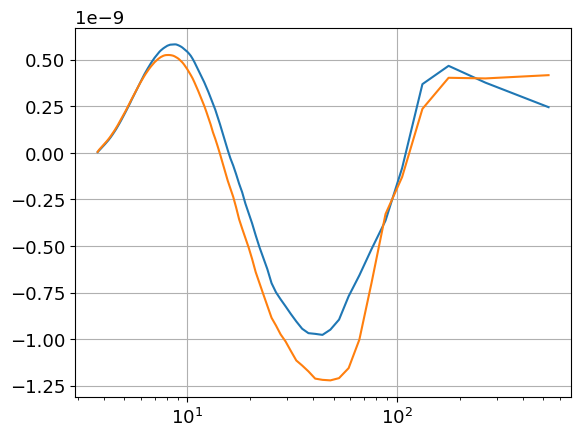

In [39]:
data=sio.loadmat('wave_fftspec.mat')
specFlux_mean=data['specFlux_mean'][0,:]
K1D=data['K1D'][0,:]
plt.semilogx(1/K1D/1e3,specFlux_mean)
data=sio.loadmat('nowave_fftspec.mat')
specFlux_mean=data['specFlux_mean'][0,:]
plt.semilogx(1/K1D/1e3,specFlux_mean)

plt.grid(True)
plt.show()

# check cg using xscale